In [1]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict

In [3]:
# define the state

class BatsmanState(TypedDict):
    runs: int
    balls: int
    fours: int
    sixes: int
    strike_rate: float
    boundary_rate: float
    summary: str


def calculate_strike_rate(state: BatsmanState) -> BatsmanState:
    runs = state["runs"]
    balls = state["balls"]
    strike_rate = (runs / balls) * 100

    return {"strike_rate": round(strike_rate, 2)}


def calculate_boundary_rate(state: BatsmanState) -> BatsmanState:
    runs = state["runs"]
    fours = state["fours"]
    sixes = state["sixes"]
    boundary_runs = (fours * 4) + (sixes * 6)
    boundary_rate = (boundary_runs / runs) * 100

    return {"boundary_rate": round(boundary_rate, 2)}


def generate_summary(state: BatsmanState) -> BatsmanState:
    summary = (
        f"Scored {state['runs']} runs off {state['balls']} balls.\n"
        f"Strike rate: {state['strike_rate']}\n"
        f"Boundary rate: {state['boundary_rate']}% of runs came from boundaries"
    )

    return {"summary": summary}


# define the Graph and pass the state to it
graph = StateGraph(BatsmanState)


# add nodes to the graph
graph.add_node("calculate_strike_rate", calculate_strike_rate)
graph.add_node("calculate_boundary_rate", calculate_boundary_rate)
graph.add_node("generate_summary", generate_summary)


# add edges to the graph
# both nodes fan out from START and run in parallel, then fan in to the summary node
graph.add_edge(START, "calculate_strike_rate")
graph.add_edge(START, "calculate_boundary_rate")
graph.add_edge("calculate_strike_rate", "generate_summary")
graph.add_edge("calculate_boundary_rate", "generate_summary")
graph.add_edge("generate_summary", END)

# Compile the graph
workflow = graph.compile()

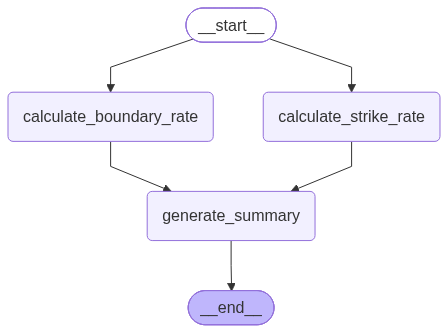

In [4]:
# visualize the graph
from IPython.display import Image

Image(workflow.get_graph().draw_mermaid_png())

In [5]:
# execute the graph with some initial state
initial_state = {"runs": 84, "balls": 51, "fours": 9, "sixes": 4}

output_state = workflow.invoke(initial_state)
print(output_state["summary"])

Scored 84 runs off 51 balls.
Strike rate: 164.71
Boundary rate: 71.43% of runs came from boundaries
